# Final Data Analysis Project

In [1]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "date": [
        "2026-01-05", "2026-01-08", "2026-01-12",
        "2026-02-03", "2026-02-10", "2026-02-18",
        "2026-03-02", "2026-03-15", "2026-03-22"
    ],
    "city": [
        "Baku", "Baku", "Tehran",
        "Tehran", "Baku", "Tehran",
        "Baku", "Tehran", "Baku"
    ],
    "product": [
        "Laptop", "Mouse", "Laptop",
        "Keyboard", "Laptop", "Mouse",
        "Keyboard", "Laptop", "Mouse"
    ],
    "quantity": [2, 10, 1, 5, 3, 8, 6, 2, 12],
    "price": [1200, 30, 1200, 70, 1200, 30, 70, 1200, 30]
})

df

,date,city,product,quantity,price
0,2026-01-05,Baku,Laptop,2,1200
1,2026-01-08,Baku,Mouse,10,30
2,2026-01-12,Tehran,Laptop,1,1200
3,2026-02-03,Tehran,Keyboard,5,70
4,2026-02-10,Baku,Laptop,3,1200
5,2026-02-18,Tehran,Mouse,8,30
6,2026-03-02,Baku,Keyboard,6,70
7,2026-03-15,Tehran,Laptop,2,1200
8,2026-03-22,Baku,Mouse,12,30


## Inspect the Data

In [2]:
# Prrview the data

df.head()

,date,city,product,quantity,price
0,2026-01-05,Baku,Laptop,2,1200
1,2026-01-08,Baku,Mouse,10,30
2,2026-01-12,Tehran,Laptop,1,1200
3,2026-02-03,Tehran,Keyboard,5,70
4,2026-02-10,Baku,Laptop,3,1200


In [3]:
# Check rows and columns

df.shape

(9, 5)

In [4]:
# Inspect data types and missing values

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   date      9 non-null      str  
 1   city      9 non-null      str  
 2   product   9 non-null      str  
 3   quantity  9 non-null      int64
 4   price     9 non-null      int64
dtypes: int64(2), str(3)
memory usage: 681.0 bytes


In [5]:
# Generate statistical summary

df.describe()

,quantity,price
count,9.000000,9.000000
mean,5.444444,558.888889
std,3.876568,608.408671
min,1.000000,30.000000
25%,2.000000,30.000000
50%,5.000000,70.000000
75%,8.000000,1200.000000
max,12.000000,1200.000000


## Conver Data Types

In [6]:
# Conver date  to datetime

df['date'] = pd.to_datetime(df['date'])

df.dtypes

date        datetime64[us]
city                   str
product                str
quantity             int64
price                int64
dtype: object

## Create New Column

In [7]:
df['revenue'] = df['quantity'] * df['price']

df

,date,city,product,quantity,price,revenue
0,2026-01-05,Baku,Laptop,2,1200,2400
1,2026-01-08,Baku,Mouse,10,30,300
2,2026-01-12,Tehran,Laptop,1,1200,1200
3,2026-02-03,Tehran,Keyboard,5,70,350
4,2026-02-10,Baku,Laptop,3,1200,3600
5,2026-02-18,Tehran,Mouse,8,30,240
6,2026-03-02,Baku,Keyboard,6,70,420
7,2026-03-15,Tehran,Laptop,2,1200,2400
8,2026-03-22,Baku,Mouse,12,30,360


## Extract Date Information

In [8]:
# Year

df['year'] = df['date'].dt.year

# Month

df['month'] = df['date'].dt.month

# Month name

df['month_name'] = df['date'].dt.month_name()

df

,date,city,product,quantity,price,revenue,year,month,month_name
0,2026-01-05,Baku,Laptop,2,1200,2400,2026,1,January
1,2026-01-08,Baku,Mouse,10,30,300,2026,1,January
2,2026-01-12,Tehran,Laptop,1,1200,1200,2026,1,January
3,2026-02-03,Tehran,Keyboard,5,70,350,2026,2,February
4,2026-02-10,Baku,Laptop,3,1200,3600,2026,2,February
5,2026-02-18,Tehran,Mouse,8,30,240,2026,2,February
6,2026-03-02,Baku,Keyboard,6,70,420,2026,3,March
7,2026-03-15,Tehran,Laptop,2,1200,2400,2026,3,March
8,2026-03-22,Baku,Mouse,12,30,360,2026,3,March


## Basic Statistics

In [9]:
# Calculate total revenue

df['revenue'].sum()

np.int64(11270)

In [10]:
# Calculate average revenue

df['revenue'].mean()

np.float64(1252.2222222222222)

In [11]:
# Find maximum revenue

df['revenue'].max()

np.int64(3600)

## Grouped Analysis

In [12]:
# Calculae quantity sold by product

df.groupby('product')['quantity'].sum()

product
Keyboard    11
Laptop       8
Mouse       30
Name: quantity, dtype: int64

## Report --> Multiple Aggregations

In [13]:
report = df.groupby('city').agg(
    total = ('revenue', 'sem'),
    average = ('revenue', 'mean')
).reset_index()

report

,city,total,average
0,Baku,674.192851,1416.0
1,Tehran,499.255696,1047.5


## Pivot Table

In [14]:
pivot = pd.pivot_table(
    df,
    values = 'revenue',
    index = 'city',
    columns = 'product',
    aggfunc = 'sum',
    fill_value = 0
)
pivot

product,Keyboard,Laptop,Mouse
city,,,
Baku,420,6000,660
Tehran,350,3600,240


## Filtering

In [15]:
high_sales = df[df['revenue'] > 1000]

high_sales

,date,city,product,quantity,price,revenue,year,month,month_name
0,2026-01-05,Baku,Laptop,2,1200,2400,2026,1,January
2,2026-01-12,Tehran,Laptop,1,1200,1200,2026,1,January
4,2026-02-10,Baku,Laptop,3,1200,3600,2026,2,February
7,2026-03-15,Tehran,Laptop,2,1200,2400,2026,3,March


In [16]:
baku_sales = df[df['city'] == 'Baku']

baku_sales

,date,city,product,quantity,price,revenue,year,month,month_name
0,2026-01-05,Baku,Laptop,2,1200,2400,2026,1,January
1,2026-01-08,Baku,Mouse,10,30,300,2026,1,January
4,2026-02-10,Baku,Laptop,3,1200,3600,2026,2,February
6,2026-03-02,Baku,Keyboard,6,70,420,2026,3,March
8,2026-03-22,Baku,Mouse,12,30,360,2026,3,March


## Sorting

In [17]:
df.sort_values('revenue', ascending = False)

,date,city,product,quantity,price,revenue,year,month,month_name
4,2026-02-10,Baku,Laptop,3,1200,3600,2026,2,February
0,2026-01-05,Baku,Laptop,2,1200,2400,2026,1,January
7,2026-03-15,Tehran,Laptop,2,1200,2400,2026,3,March
2,2026-01-12,Tehran,Laptop,1,1200,1200,2026,1,January
6,2026-03-02,Baku,Keyboard,6,70,420,2026,3,March
8,2026-03-22,Baku,Mouse,12,30,360,2026,3,March
3,2026-02-03,Tehran,Keyboard,5,70,350,2026,2,February
1,2026-01-08,Baku,Mouse,10,30,300,2026,1,January
5,2026-02-18,Tehran,Mouse,8,30,240,2026,2,February


## Create Categories

In [18]:
def level(value):
    if value >= 2000:
        return 'High'
    if value >= 500:
        return 'Medium'
    else:
        return 'Low'


In [19]:
df['sales_level'] = df['revenue'].apply(level)
df

,date,city,product,quantity,price,revenue,year,month,month_name,sales_level
0,2026-01-05,Baku,Laptop,2,1200,2400,2026,1,January,High
1,2026-01-08,Baku,Mouse,10,30,300,2026,1,January,Low
2,2026-01-12,Tehran,Laptop,1,1200,1200,2026,1,January,Medium
3,2026-02-03,Tehran,Keyboard,5,70,350,2026,2,February,Low
4,2026-02-10,Baku,Laptop,3,1200,3600,2026,2,February,High
5,2026-02-18,Tehran,Mouse,8,30,240,2026,2,February,Low
6,2026-03-02,Baku,Keyboard,6,70,420,2026,3,March,Low
7,2026-03-15,Tehran,Laptop,2,1200,2400,2026,3,March,High
8,2026-03-22,Baku,Mouse,12,30,360,2026,3,March,Low


## Missing Values

In [24]:
# Create a missing value

df.loc[2, 'price'] = np.nan
df

,date,city,product,quantity,price,revenue,year,month,month_name,sales_level
0,2026-01-05,Baku,Laptop,2,1200.0,2400,2026,1,January,High
1,2026-01-08,Baku,Mouse,10,30.0,300,2026,1,January,Low
2,2026-01-12,Tehran,Laptop,1,NaN,1200,2026,1,January,Medium
3,2026-02-03,Tehran,Keyboard,5,70.0,350,2026,2,February,Low
4,2026-02-10,Baku,Laptop,3,1200.0,3600,2026,2,February,High
5,2026-02-18,Tehran,Mouse,8,30.0,240,2026,2,February,Low
6,2026-03-02,Baku,Keyboard,6,70.0,420,2026,3,March,Low
7,2026-03-15,Tehran,Laptop,2,1200.0,2400,2026,3,March,High
8,2026-03-22,Baku,Mouse,12,30.0,360,2026,3,March,Low


In [21]:
df.isna().sum()

date           0
city           0
product        0
quantity       0
price          1
revenue        0
year           0
month          0
month_name     0
sales_level    0
dtype: int64

In [22]:
# Fill missing price with the mean

df['price'] = df['price'].fillna(df['price'].mean())

In [23]:
df

,date,city,product,quantity,price,revenue,year,month,month_name,sales_level
0,2026-01-05,Baku,Laptop,2,1200.00,2400,2026,1,January,High
1,2026-01-08,Baku,Mouse,10,30.00,300,2026,1,January,Low
2,2026-01-12,Tehran,Laptop,1,478.75,1200,2026,1,January,Medium
3,2026-02-03,Tehran,Keyboard,5,70.00,350,2026,2,February,Low
4,2026-02-10,Baku,Laptop,3,1200.00,3600,2026,2,February,High
5,2026-02-18,Tehran,Mouse,8,30.00,240,2026,2,February,Low
6,2026-03-02,Baku,Keyboard,6,70.00,420,2026,3,March,Low
7,2026-03-15,Tehran,Laptop,2,1200.00,2400,2026,3,March,High
8,2026-03-22,Baku,Mouse,12,30.00,360,2026,3,March,Low


# Visulization

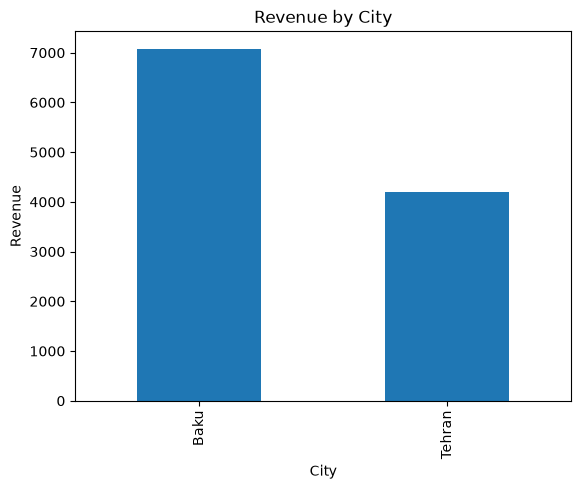

In [25]:
import matplotlib.pyplot as plt

city_revenue = df.groupby("city")["revenue"].sum()

city_revenue.plot(kind="bar")

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

## Product Analysis

In [26]:
product_revenue = (
    df.groupby("product")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue

product
Laptop      9600
Mouse        900
Keyboard     770
Name: revenue, dtype: int64

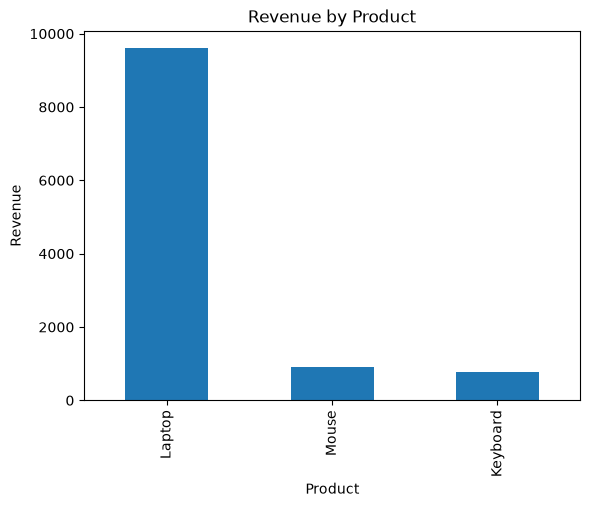

In [27]:
product_revenue.plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

## Monthly Analysis

In [28]:
monthly_revenue = (
    df.groupby("month")["revenue"]
    .sum()
)

monthly_revenue

month
1    3900
2    4190
3    3180
Name: revenue, dtype: int64

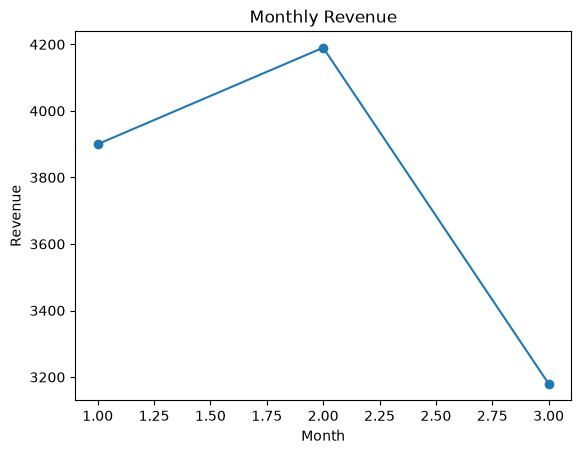

In [29]:
monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

## Find Best Product

In [30]:
best_product = (
    df.groupby("product")["revenue"]
    .sum()
    .idxmax()
)

best_product

'Laptop'

In [31]:
best_revenue = (
    df.groupby("product")["revenue"]
    .sum()
    .max()
)

best_revenue

np.int64(9600)

## Finall Sumary Report

In [32]:
final_report = df.groupby("product").agg(
    total_quantity=("quantity", "sum"),
    total_revenue=("revenue", "sum"),
    average_revenue=("revenue", "mean")
).sort_values(
    "total_revenue",
    ascending=False
)

final_report

,total_quantity,total_revenue,average_revenue
product,,,
Laptop,8,9600,2400.0
Mouse,30,900,300.0
Keyboard,11,770,385.0


## End-to-End Data Analysis Workflow